# Experiment: Million Songs Dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,RidgeCV
from sklearn import preprocessing
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample

import torch
from torch.utils.data import Dataset,DataLoader
from torch import optim
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.nn.functional as F

import psutil, os 
import random
df=pd.read_csv('../../data/YearPredictionMSD/YearPredictionMSD.txt',header=None,sep = ',')
tt=463715
ee=51630
train=df.iloc[:tt] 
test=df.iloc[tt:] 

train_y = train[0]
test_y = test[0] #response:year
train_x = train
test_x = test
del train_x[0]
del test_x[0]
total_x=pd.concat([train_x,test_x])
x=preprocessing.StandardScaler().fit(total_x).transform(total_x) #normalize
x=pd.DataFrame(x)
train_x=x.iloc[:tt]
test_x=x.iloc[tt:]

train_x.reset_index(drop=True, inplace=True) 
test_x.reset_index(drop=True, inplace=True) 
train_y.reset_index(drop=True, inplace=True) 
test_y.reset_index(drop=True, inplace=True) 

train_x ##display the data

,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
0,1.080575,0.391265,1.826532,0.464657,-0.474730,-0.278204,-1.552371,-1.310845,0.387704,-0.666166,...,-0.085335,0.108508,0.142775,-0.237355,0.049233,-0.356182,0.544458,-0.470599,-0.255977,0.042292
1,0.880919,0.332292,1.748539,0.721828,-0.164945,-1.191173,0.765681,0.109626,1.420941,0.414950,...,-0.314250,0.306236,-0.069483,0.052017,-0.632328,-0.436057,0.556448,0.568744,0.206940,1.158587
2,1.247622,0.592600,1.337173,0.750657,-0.001110,-0.702100,-0.060914,-0.069956,1.166254,-0.074608,...,-0.396186,0.566683,-0.756534,-0.284019,-0.024220,0.223128,-0.509789,-0.338457,0.105819,-0.090208
3,0.801044,-0.061805,0.783683,0.087218,0.329180,-1.298429,0.510714,-1.073355,-0.016803,-1.262655,...,0.586237,-0.559427,-0.478689,-0.890161,-0.793906,0.567269,-0.263107,0.408116,0.967862,0.793384
4,1.249775,0.793334,1.657037,0.447460,-0.406775,-0.567138,-0.692498,-0.952197,0.841844,-0.144910,...,-0.181585,0.099672,0.191319,-0.585576,-0.111877,-0.219960,0.448804,0.256882,0.192038,1.241363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463710,0.493427,-0.336316,-0.084681,-0.658594,-1.673199,0.282011,-1.493945,-0.686837,0.831008,-1.058139,...,0.124247,0.991760,-0.324729,-0.395601,1.531331,0.085218,-0.001498,-0.322949,-0.616705,-0.697774
463711,-0.124812,0.200480,-0.926193,-0.897601,-1.643501,-0.375450,0.622636,-0.478409,0.758789,-1.016975,...,-0.372135,1.868488,-0.549899,-0.652146,2.410029,0.030487,-1.189134,-0.120523,0.468067,-0.343264
463712,0.162997,0.006509,0.836644,0.067344,-0.367053,0.273406,-2.079877,-0.029351,-0.221383,-0.722086,...,-0.103120,0.440416,-0.406601,-0.822279,0.864693,-0.687515,-0.265901,-0.663702,0.012903,-0.246192
463713,0.247234,0.249282,-0.407312,-1.278516,-2.290479,-0.373539,-0.105010,0.164208,-0.146179,0.030704,...,0.367180,1.480824,0.126993,-0.701360,1.256892,0.637414,0.344071,0.532877,0.466592,0.700802


In [30]:
train_x=train_x.to_numpy()
train_y=train_y.to_numpy()
test_x=test_x.to_numpy()
test_y=test_y.to_numpy()

In [2]:
nntrain_x = torch.from_numpy(train_x.to_numpy()).float()
nntrain_y = torch.squeeze(torch.from_numpy(train_y.to_numpy()).float()) 
nntest_x= torch.from_numpy(test_x.to_numpy()).float()
nntest_y = torch.squeeze(torch.from_numpy(test_y.to_numpy()).float())

class mydataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y
        self._len = len(x)

    def __getitem__(self, item): 
        return self._x[item], self._y[item]

    def __len__(self):
        return self._len

In [16]:
GLOBAL_SEED = 7199   # or any integer you choose

def set_global_seed(seed: int):
    if seed is None:
        seed = GLOBAL_SEED
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
def measure_time(func, *args, **kwargs):
    """
    Measure wall-clock time of func(*args, **kwargs).
    Returns (result, runtime_in_seconds).
    """
    t0 = time.time()
    result = func(*args, **kwargs)
    t1 = time.time()
    return result, (t1 - t0)


def measure_memory_cpu(func, *args, **kwargs):
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss  # bytes

    result = func(*args, **kwargs)

    mem_after = process.memory_info().rss
    delta_mb = (mem_after - mem_before) / 1024**2
    after_mb = mem_after / 1024**2

    return result, delta_mb, after_mb


def measure_memory_gpu(func, *args, **kwargs):
    """
    Measure peak GPU memory allocated during func().
    Returns: (result, peak_MB or None)
    """
    if not torch.cuda.is_available():
        return func(*args, **kwargs), None

    torch.cuda.reset_peak_memory_stats()

    result = func(*args, **kwargs)

    peak_bytes = torch.cuda.max_memory_allocated()
    peak_mb = peak_bytes / 1024**2

    return result, peak_mb


## 1. DNN

In [18]:

class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.fc1 = nn.Linear(90, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)


In [32]:

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0.01)

def run_dnn(train_x, train_y, test_x, test_y,
            batch_size=256,
            max_epochs=1000,
            early_stop_window=50,
            lr=1e-4,
            momentum=0.9,
            weight_decay=1e-2,
            device=None,
            verbose=False,
            seed=7199):
    """
    Train the DNN and return (train_mse, test_mse, num_epochs_run).
    No timing or memory measurement inside.
    """

    set_global_seed(seed)
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    # numpy -> tensors

    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x  = torch.from_numpy(test_x).float()
    nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=batch_size,shuffle=False)

    net = Net()
    net = net.to(device)
    net.apply(init_weights)

    criterion=nn.MSELoss() 
    optimizer=optim.SGD(net.parameters(),lr=lr,momentum=momentum,weight_decay=weight_decay) #optim.Adam(...)
    dnn_trainloss=[]
    dnn_testloss=[]
    #tb=0
    #tc=0

    for epoch in range(1000):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

        net.eval()
        with torch.no_grad():
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            dnn_trainloss.append(mean_squared_error(train_y, pred_train))

            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            dnn_testloss.append(mean_squared_error(test_y, pred_test))

        if epoch > early_stop_window and float(dnn_trainloss[-1]) > max(dnn_trainloss[-50:-1]):
            break

        if verbose and epoch % 50 == 0:
            print(f"epoch {epoch:4d}  train MSE: {dnn_trainloss[-1]:.6f}  "
                    f"test MSE: {dnn_testloss[-1]:.6f}")

    num_epochs_run = len(dnn_trainloss)
    final_train_mse = dnn_trainloss[-1]
    final_test_mse  = dnn_testloss[-1]

    return final_train_mse, final_test_mse, num_epochs_run

In [33]:
def dnn_core():
    return run_dnn(train_x, train_y, test_x, test_y)

# GPU wrapper inside, CPU wrapper around it, then time
((dnn_result, dnn_peak_gpu_mb), dnn_delta_cpu_mb, dnn_cpu_after_mb), dnn_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(dnn_core)
    )
)


dnn_train_mse, dnn_test_mse, dnn_epochs = dnn_result

print("DNN train MSE:", dnn_train_mse)
print("DNN test MSE:",  dnn_test_mse)
print("DNN time:", dnn_time)
print("DNN peak GPU (MB):", dnn_peak_gpu_mb)
print("DNN CPU Δ (MB):", dnn_delta_cpu_mb)
print("DNN CPU final (MB):", dnn_cpu_after_mb)

DNN train MSE: 219.27552795410156
DNN test MSE: 219.56211853027344
DNN time: 395.6250219345093
DNN peak GPU (MB): None
DNN CPU Δ (MB): 2470.953125
DNN CPU final (MB): 2584.359375


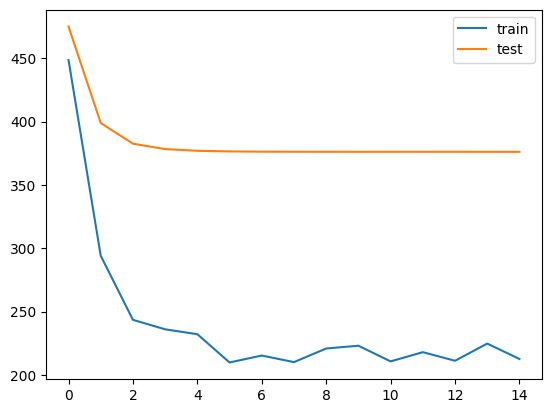

In [ ]:
plt.plot(dnn_train_mse[:])
plt.plot(dnn_test_mse[:])
plt.legend(["train","test"])

## 2. Resnet

In [36]:
train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=1024, shuffle=True)
test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=1024, shuffle=False)

class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(infeatures,outfeatures)
    
    def forward(self, x):
        y = self.fc1(x)
        y= F.relu(y)
        x = self.fc2(x)
        return F.relu(x+y)


class ResNet(nn.Module): 
    def __init__(self):
        super(ResNet, self).__init__()
        self.rblock1 = ResidualBlock(90,256)
        self.rblock2 = ResidualBlock(256,128)
        self.rblock3 = ResidualBlock(128,64)
        self.fc4 = nn.Linear(64,1)
    
 
    def forward(self, x):
        x = self.rblock1(x)
        x = self.rblock2(x)
        x = self.rblock3(x)
        return self.fc4(x)
#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=0.1)
        m.bias.data.fill_(0.01)

In [37]:
def run_resnet(train_x, train_y, test_x, test_y,
               batch_size=256,
               max_epochs=1000,
               early_stop_window=50,
               lr=1e-4,
               momentum=0.9,
               weight_decay=1e-2,
               device=None,
               verbose=False,
               seed=7199):
    """
    Train a ResNet on tabular input and return:
        (train_mse, test_mse, num_epochs_run)
    No timing or memory measurements inside.
    """

    # ========================
    # 1. Reproducibility
    # ========================
    set_global_seed(seed)

    # Determine device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # ========================
    # 2. Convert NumPy → Tensors
    # ========================
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x  = torch.from_numpy(test_x).float()
    nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )

    test_loader = DataLoader(
        mydataset(nntest_x, nntest_y),
        batch_size=batch_size, shuffle=False
    )

    # ========================
    # 3. Model, Loss, Optimizer
    # ========================
    net = ResNet().to(device)
    net.apply(init_weights)      # keep your initialization

    criterion = nn.MSELoss()

    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # ========================
    # 4. Training Loop
    # ========================
    res_trainloss = []
    res_testloss  = []
    for epoch in range(max_epochs):

        # ---- Training ----
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()

        # ---- Evaluation ----
        net.eval()
        with torch.no_grad():
            # full train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            res_trainloss.append(train_mse)

            # full test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            res_testloss.append(test_mse)

        # ---- Early Skipping ----
        if epoch > early_stop_window:
            if res_trainloss[-1] > max(res_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # ---- Optional Printing ----
        if verbose and epoch % 50 == 0:
            print(f"""epoch {epoch}
                Train MSE: {train_mse}
                Test  MSE: {test_mse}
            """)

    # final metrics
    num_epochs_run = len(res_trainloss)
    final_train_mse = res_trainloss[-1]
    final_test_mse  = res_testloss[-1]
    return final_train_mse, final_test_mse, num_epochs_run


In [38]:
def resnet_core():
    return run_resnet(train_x, train_y, test_x, test_y)

((res_result, res_peak_gpu), res_delta_cpu, res_cpu_after), res_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(resnet_core)
    )
)

res_train_mse, res_test_mse, res_epochs = res_result

print("ResNet Train MSE:", res_train_mse)
print("ResNet Test  MSE:", res_test_mse)
print("ResNet Epochs:", res_epochs)
print("ResNet Time:", res_time)
print("ResNet CPU ΔMB:", res_delta_cpu)
print("ResNet GPU peak MB:", res_peak_gpu)


ResNet Train MSE: 219.0076904296875
ResNet Test  MSE: 219.29132080078125
ResNet Epochs: 218
ResNet Time: 1332.841454744339
ResNet CPU ΔMB: 3574.15625
ResNet GPU peak MB: None


# Random Feature

In [9]:
def sample_1d(pdf, gamma, device):
    if pdf == 'G':
        w = torch.randn(1, device=device) * gamma
        return w
    elif pdf == 'L':
        w = torch.distributions.laplace.Laplace(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device)).sample() * gamma
        return w
    elif pdf == 'C':
        w = torch.distributions.cauchy.Cauchy(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device)).sample() * gamma
        return w
    
def sample(pdf, gamma, d, device):
    return torch.tensor([sample_1d(pdf, gamma, device) for _ in range(d)], device=device)

class RandomFourierFeature:
    """Random Fourier Feature
    Parameters
    ----------
    d : int
        Input space dimension
    D : int
        Feature space dimension
    W : shape (D,d)
    b : shape (D)
    kernel : char
        Kernel to use; 'G', 'L', or 'C'
    gamma : float
        pdf parameter
    """
    
    def __init__(self, d, D, W=None, b=None, kernel='G', gamma=1, device='cpu'):
        self.d = d
        self.D = D
        self.gamma = gamma
        self.device = device

        kernel = kernel.upper()
        if kernel not in ['G', 'L', 'C']:
            raise Exception('Invalid Kernel')
        self.kernel = kernel

        if W is None or b is None:
            self.create()
        else:
            self.__load(W, b)

    def __load(self, W, b):
        """Load from existing Arrays"""

        self.W = W.reshape([self.D, self.d])
        self.b = b
    
    
    def create(self):
        """Create a d->D fourier random feature"""
        self.b = torch.rand(self.D, device=self.device) * 2 * torch.pi
        self.W = sample(self.kernel, self.gamma, self.d * self.D, self.device).reshape(self.D, self.d)

    def transform(self, x):
        """Transform a vector using this feature
        Parameters
        ----------
        x : (shape=(n,d))
            to transform; must be single dimension vector
        Returns
        -------
        x : (shape=(n,D))
            Feature space transformation of x
        """
        #print(self.W.shape,self.b.reshape(-1,1).shape,x.shape)
        #print((self.W @ x.T).shape)
       

        result = torch.sqrt(torch.tensor([2.0 / self.D], device=x.device)) * torch.cos(
            self.W @ x.T + (self.b.reshape(-1, 1) @ torch.ones((1,len(x)), device=x.device))
        )
        return result.T
    

# 3. MLKM

In [39]:
train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=1024, shuffle=True)
test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=1024, shuffle=False)

rff0=RandomFourierFeature(90,256,kernel='C',gamma=0.02)
rff1=RandomFourierFeature(128,128,kernel='G',gamma=0.1)
rff2=RandomFourierFeature(64,64,kernel='G',gamma=0.5)

class KernelNet(nn.Module): 
    def __init__(self):
        super(KernelNet, self).__init__()
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = rff0.transform(x)
        x=self.fc1(x)
        x = rff1.transform(x)
        x=self.fc2(x)
        x = rff2.transform(x)
        return self.fc3(x)


#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=1)
        m.bias.data.fill_(0.01)


In [40]:
def run_mlkm(train_x, train_y, test_x, test_y,
             batch_size=256,
             max_epochs=1000,
             early_stop_window=50,
             lr=7e-4,
             momentum=0.95,
             weight_decay=1e-3,
             device=None,
             verbose=False,
             seed=7199):
    """
    Train KernelNet (MLKM) and return:
        (train_mse, test_mse, num_epochs_run)

    No timing or memory measurement inside.
    """

    # -----------------------
    # 1. Reproducibility
    # -----------------------
    set_global_seed(seed)

    # Device
    if device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # -----------------------
    # 2. NumPy -> Tensors
    # -----------------------
    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    # nntest_x  = torch.from_numpy(test_x).float()
    # nntest_y  = torch.from_numpy(test_y).float().squeeze()

    train_loader = DataLoader(
        mydataset(nntrain_x, nntrain_y),
        batch_size=batch_size, shuffle=True
    )
    # test_loader = DataLoader(
    #     mydataset(nntest_x, nntest_y),
    #     batch_size=batch_size, shuffle=False
    # )

    # -----------------------
    # 4. Model, Loss, Optimizer
    # -----------------------
    net = KernelNet().to(device)

    # match your original code: reseed before init_weights
    torch.manual_seed(1)
    net.apply(init_weights)

    criterion = nn.MSELoss()
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    # -----------------------
    # 5. Training Loop
    # -----------------------
    kernelnn_trainloss = []
    kernelnn_testloss  = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            train_loss.backward()
            optimizer.step()

        # ---- Evaluation (train + test MSE) ----
        net.eval()
        with torch.no_grad():
            # train MSE
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            kernelnn_trainloss.append(train_mse)

            # test MSE
            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            kernelnn_testloss.append(test_mse)

        # ---- Early stopping (same as your original) ----
        if epoch > early_stop_window:
            if kernelnn_trainloss[-1] > max(kernelnn_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

        # if verbose and epoch % 50 == 0:
        #     print(f"""epoch {epoch}
        #         Train MSE: {kernelnn_trainloss[-1]}
        #         Test  MSE: {kernelnn_testloss[-1]}
        #     """)

    num_epochs_run = len(kernelnn_trainloss)
    final_train_mse = kernelnn_trainloss[-1]
    final_test_mse  = kernelnn_testloss[-1]

    return final_train_mse, final_test_mse, num_epochs_run


In [41]:
def mlkm_core():
    return run_mlkm(train_x, train_y, test_x, test_y)

((mlkm_result, mlkm_peak_gpu), mlkm_delta_cpu, mlkm_cpu_after), mlkm_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(mlkm_core)
    )
)

mlkm_train_mse, mlkm_test_mse, mlkm_epochs = mlkm_result

print("MLKM train MSE:", mlkm_train_mse)
print("MLKM test  MSE:", mlkm_test_mse)
print("MLKM epochs run:", mlkm_epochs)
print("MLKM time:", mlkm_time)
print("MLKM CPU ΔMB:", mlkm_delta_cpu)
print("MLKM GPU peak MB:", mlkm_peak_gpu)


MLKM train MSE: 122.93562316894531
MLKM test  MSE: 121.38897705078125
MLKM epochs run: 84
MLKM time: 361.13787293434143
MLKM CPU ΔMB: -0.0625
MLKM GPU peak MB: None


# 4. Residual multilayer learning

In [43]:
train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=1024, shuffle=True)
test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=1024, shuffle=False)

rff0=RandomFourierFeature(90,256,kernel='C',gamma=0.02)
rff1=RandomFourierFeature(128,128,kernel='G',gamma=0.1)
rff2=RandomFourierFeature(64,64,kernel='G',gamma=0.5)


class ResidualBlock(nn.Module):
    def __init__(self,infeatures,outfeatures,rff):
        super(ResidualBlock,self).__init__()
        self.infeatures = infeatures
        self.outfeatures = outfeatures
        self.rff=rff
        
        self.fc1 = nn.Linear(infeatures,outfeatures)
        self.fc2 = nn.Linear(outfeatures,outfeatures)
    
    def forward(self, x):
        rff=self.rff
        x = self.fc1(x)
        y = rff.transform(x)
        y = self.fc2(y)
        return x+y

class ResKernelNet(nn.Module): 
    def __init__(self):
        super(ResKernelNet, self).__init__()
        self.rblock1 = ResidualBlock(256,128,rff1)
        self.rblock2 = ResidualBlock(128,64,rff2)
        self.fc3 =nn.Linear(64,1)
 
    def forward(self, x):
        x = rff0.transform(x)
        x = self.rblock1(x)
        x = self.rblock2(x)
        return self.fc3(x)

#initialize
def init_weights(m):
    if type(m) == nn.Conv2d:
        torch.nn.init.normal_(m.weight,mean=0,std=0.5)
    if type(m) == nn.Linear:
        torch.nn.init.uniform_(m.weight,a=0,b=1)
        m.bias.data.fill_(0.01)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = ResKernelNet()
net = net.to(device)
torch.manual_seed(1)
#net.apply(init_weights)
print(net)
criterion=nn.MSELoss() 
optimizer=optim.SGD(net.parameters(),lr=1e-6,momentum=0.9,weight_decay=1e-2) #optim.Adam(...)

loss=[]
reskernel_trainloss=[]
reskernel_testloss=[]
t0 = time.time()
for epoch in range(20): 
    for x, y in train_loader: #for batch, (x, y) in enumerate(train_loader): 
        x, y = x.to(device), y.to(device)
        # Compute prediction error
        y_pred = net(x)
        y_pred = torch.squeeze(y_pred)
        train_loss = criterion(y_pred, y)
        loss.append(train_loss)
        # Backpropagation
        optimizer.zero_grad() 
        train_loss.backward()
        optimizer.step()
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_test_pred = net(x)
        y_test_pred = torch.squeeze(y_test_pred)

        test_loss = criterion(y_test_pred,y)
            
    if epoch>5 and float(test_loss)>max(reskernel_testloss[-5:-1]):
        break
    
    
    if epoch % 2 == 0:         
        print(f'''epoch {epoch}
            Train set - loss: {train_loss}
            Test  set - loss: {test_loss}
            ''')
    reskernel_trainloss.append(float(train_loss))
    reskernel_testloss.append(float(test_loss))
        
    
dnn_fit = time.time() - t0
print("Residual KernelNet complexity and model fitted in %.3f s" % dnn_fit)

ResKernelNet(
  (rblock1): ResidualBlock(
    (fc1): Linear(in_features=256, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
  )
  (rblock2): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=64, bias=True)
    (fc2): Linear(in_features=64, out_features=64, bias=True)
  )
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)
epoch 0
            Train set - loss: 116.63724517822266
            Test  set - loss: 441.20001220703125
            
epoch 2
            Train set - loss: 107.29132080078125
            Test  set - loss: 419.8493347167969
            
epoch 4
            Train set - loss: 103.05772399902344
            Test  set - loss: 403.4612731933594
            
epoch 6
            Train set - loss: 108.8039779663086
            Test  set - loss: 365.19891357421875
            
epoch 8
            Train set - loss: 91.19878387451172
            Test  set - loss: 355.90008544921875
            
epoch 10
        

In [ ]:
def run_RKLN(train_x, train_y, test_x, test_y,
    batch_size = 256,
    max_epochs = 1000,
    early_stop_window = 50,
    lr = 1e-6,
    momentum = 0.9,
    weight_decay = 1e-2,
    device = None,
    verbose = False,
    seed = 7199
    ):
    set_global_seed(seed)

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    nntrain_x = torch.from_numpy(train_x).float()
    nntrain_y = torch.from_numpy(train_y).float().squeeze()
    nntest_x = torch.from_numpy(test_x).float()
    
    

    train_loader = DataLoader(mydataset(nntrain_x, nntrain_y),batch_size=1024, shuffle=True)
    test_loader = DataLoader(mydataset(nntest_x, nntest_y),batch_size=1024, shuffle=False)

    rff0=RandomFourierFeature(90,256,kernel='C',gamma=0.02)
    rff1=RandomFourierFeature(128,128,kernel='G',gamma=0.1)
    rff2=RandomFourierFeature(64,64,kernel='G',gamma=0.5)
    net = ResKernelNet()
    net = net.to(device)


    criterion = nn.MSELoss()
    optimizer = optim.SGD(
        net.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay
    )

    RKLN_trainloss = []
    RKLN_testloss = []

    for epoch in range(max_epochs):
        net.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            y_pred = net(x).squeeze()
            train_loss = criterion(y_pred, y)
            loss.append(train_loss)
            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()
        net.eval()
        with torch.no_grad():
            x0 = torch.from_numpy(train_x).float().to(device)
            pred_train = net(x0).squeeze().cpu().numpy()
            train_mse = mean_squared_error(train_y, pred_train)
            RKLN_trainloss.append(train_mse)

            x1 = torch.from_numpy(test_x).float().to(device)
            pred_test = net(x1).squeeze().cpu().numpy()
            test_mse = mean_squared_error(test_y, pred_test)
            RKLN_testloss.append(test_mse)

        if epoch > early_stop_window:
            if RKLN_trainloss[-1] > max(RKLN_trainloss[-early_stop_window:-1]):
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
    num_epochs_run = len(RKLN_trainloss)
    final_train_mse = RKLN_trainloss[-1]
    final_test_mse = RKLN_testloss[-1]

    return final_train_mse, final_test_mse, num_epochs_run


In [46]:
def rkln_core():
    return run_mlkm(train_x, train_y, test_x, test_y)

((rkln_result, rkln_peak_gpu), rkln_delta_cpu, rkln_cpu_after), rkln_time = measure_time(
    lambda: measure_memory_cpu(
        lambda: measure_memory_gpu(rkln_core)
    )
)

rkln_train_mse, rkln_test_mse, rkln_epochs = rkln_result




In [ ]:
print("RKL train MSE:", rkln_train_mse)
print("RKL test  MSE:", rkln_test_mse)
print("RKL epochs run:", rkln_epochs)
print("RKL time:", rkln_time)
print("RKL CPU ΔMB:", rkln_delta_cpu)
print("RKL GPU peak MB:", rkln_peak_gpu)


RKL train MSE: 121.02520751953125
RKL test  MSE: 119.33020782470703
RKL epochs run: 80
RKL time: 437.0160400867462
RKL CPU ΔMB: 3243.359375
RKL GPU peak MB: None


In [ ]:
print(dnn_testloss[-1],res_testloss[-1], mlkm_test_mse[-1],rkln_test_mse[-1])

376.08343505859375 376.10247802734375 364.1475524902344 409.8155517578125


In [49]:
def plot_choose(fig,start,data,linestyle="-"):
    fig.plot(np.arange(start,len(data)),data[start:],linestyle=linestyle)

In [50]:
print(dnn_train_mse[-1],res_train_mse[-1],mlkm_train_mse[-1],rkln_train_mse[-1])
print(dnn_test_mse[-1],res_test_mse[-1],mlkm_test_mse[-1],rkln_test_mse[-1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_choose(ax[0],10,dnn_test_mse,linestyle="--")
plot_choose(ax[0],10,res_test_mse,linestyle="--")
plot_choose(ax[0],10,mlkm_test_mse)
plot_choose(ax[0],10,rkln_test_mse)
ax[0].legend(["NN","ResNet","MLKM","RKM"],fontsize="x-large")
ax[0].set_xlabel("epoch",fontsize="xx-large")
ax[0].set_ylabel("Test MSE",fontsize="xx-large")
ax[0].set_yscale('log')

plot_choose(ax[1],10,dnn_train_mse,linestyle="--")
plot_choose(ax[1],10,res_train_mse,linestyle="--")
plot_choose(ax[1],10,mlkm_train_mse)
plot_choose(ax[1],10,rkln_train_mse)
ax[1].legend(["NN","ResNet","MLKM","RKM"],fontsize="x-large")
ax[1].set_xlabel("epoch",fontsize="xx-large")
ax[1].set_ylabel("Train MSE",fontsize="xx-large")
ax[1].set_yscale('log')
plt.show()

TypeError: 'float' object is not subscriptable

In [ ]:
plt.plot(dnn_test_mse,linestyle="--")
plt.plot(res_test_mse,linestyle="--")
plt.plot(mlkm_test_mse)
plt.plot(rkln_test_mse)
plt.legend(["NN","ResNet","MLKM","RKM"],fontsize="x-large")
plt.xlabel("epoch",fontsize="xx-large")
plt.ylabel("Test MSE",fontsize="xx-large")
plt.yscale('log')
plt.show()